<a href="https://colab.research.google.com/github/QjaYo/Computer-Vision/blob/main/cv_assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

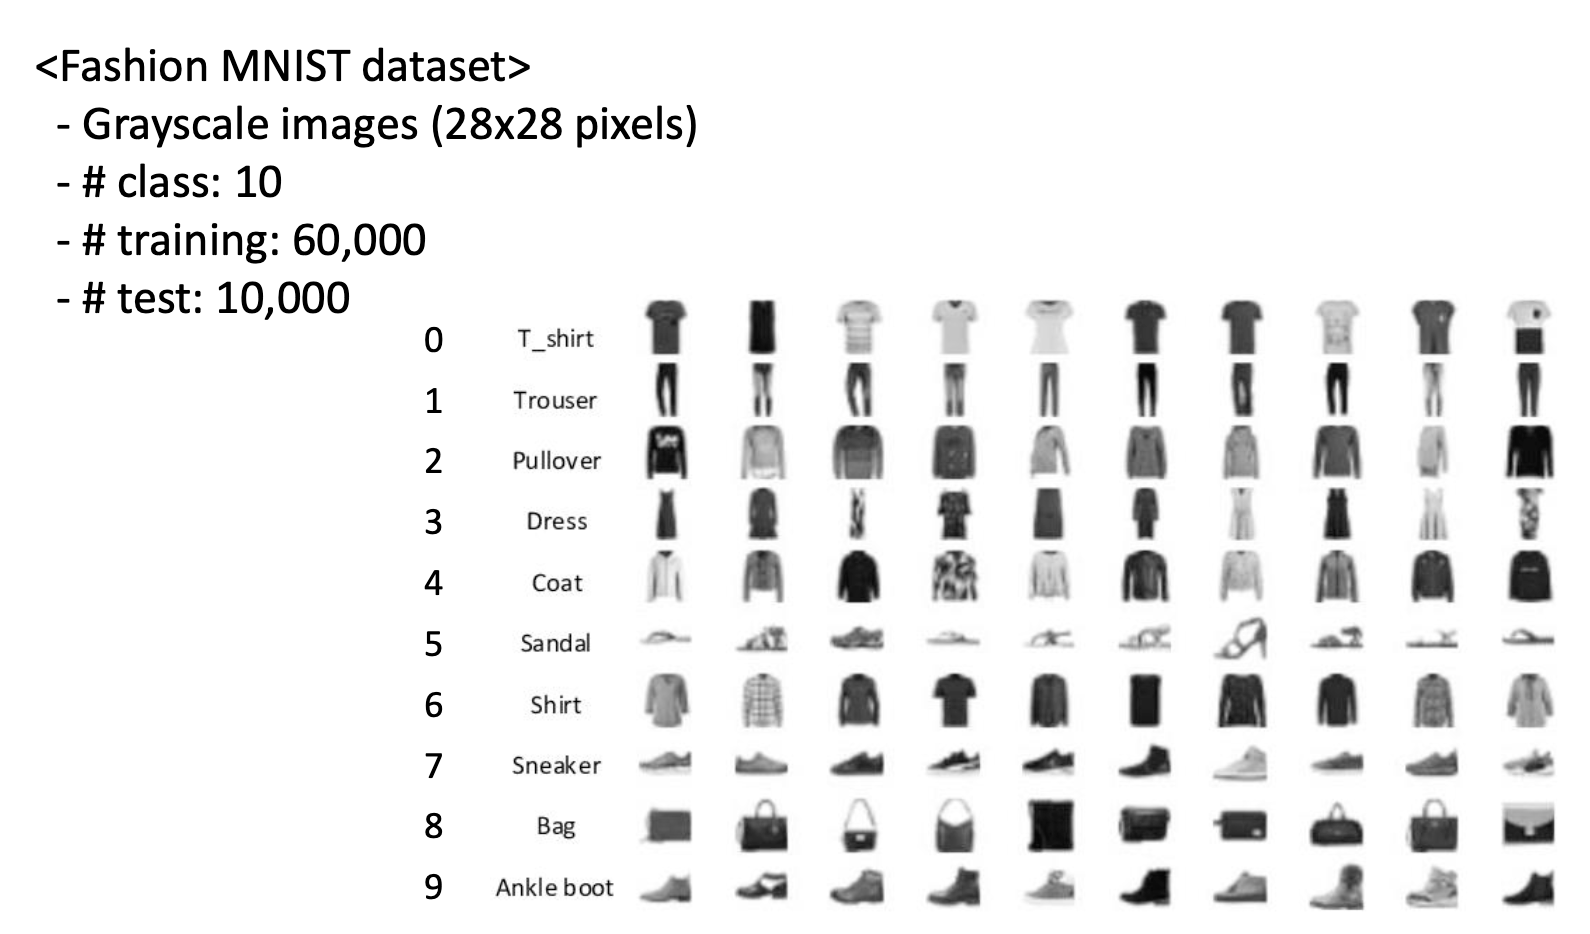

In [37]:
#1-1
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# Load fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_X, train_Y), (test_X, test_Y) = fashion_mnist.load_data()

print("[previous]")
print(train_X.shape, train_Y.shape)
print(test_X.shape, test_Y.shape)
print("test_Y: ", end='')
print(test_Y[:10], end='\n\n')

# Modify dataset
label_map = {1:0, 4:1, 7:2, 8:3, 9:4}

train_mask = np.isin(train_Y, list(label_map.keys()))
train_X = train_X[train_mask]
train_Y = np.array([label_map[y] for y in train_Y[train_mask]])

test_mask = np.isin(test_Y, list(label_map.keys()))
test_X = test_X[test_mask]
test_Y = np.array([label_map[y] for y in test_Y[test_mask]])

print("[after]")
print(train_X.shape, train_Y.shape)
print(test_X.shape, test_Y.shape)
print("test_Y: ", end='')
print(test_Y[:10])

# Normalize intensities between 0 and 1
train_X = train_X / 255.0
test_X = test_X / 255.0

[previous]
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)
test_Y: [9 2 1 1 6 1 4 6 5 7]

[after]
(30000, 28, 28) (30000,)
(5000, 28, 28) (5000,)
test_Y: [4 0 0 0 1 2 1 2 1 0]


4 [0. 0. 0. 0. 1.]
2 [0. 0. 1. 0. 0.]
4 [0. 0. 0. 0. 1.]
2 [0. 0. 1. 0. 0.]
4 [0. 0. 0. 0. 1.]
0 [1. 0. 0. 0. 0.]
1 [0. 1. 0. 0. 0.]
0 [1. 0. 0. 0. 0.]
1 [0. 1. 0. 0. 0.]
3 [0. 0. 0. 1. 0.]
(30000, 28, 28) (5000, 28, 28)


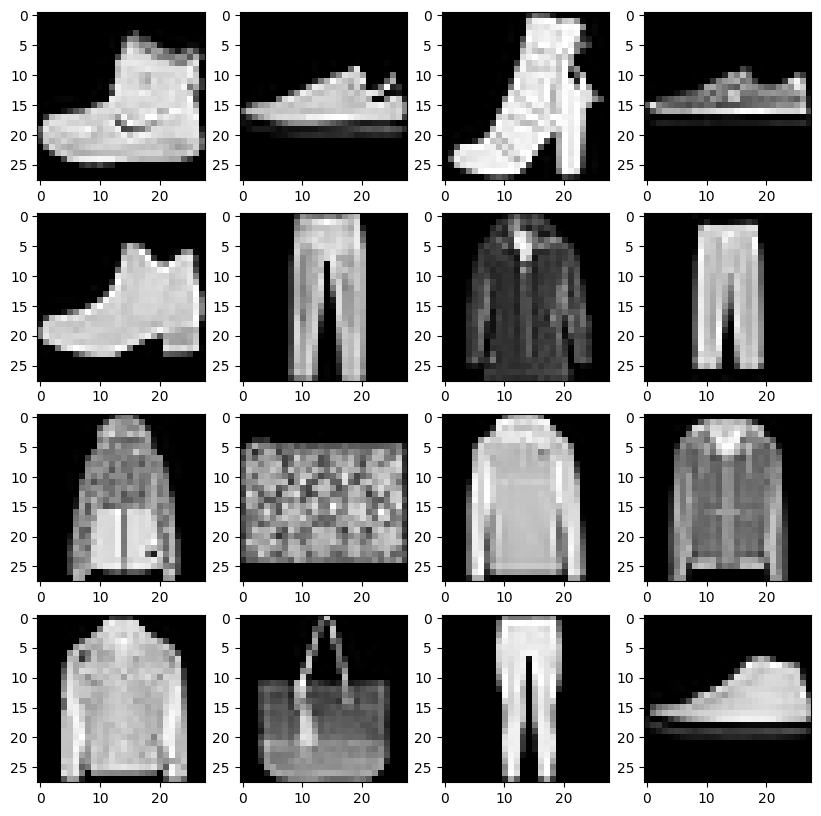

[4 2 4 2 4 0 1 0 1 3 1 1 1 3 0 2]


In [38]:
# Convert labels
train_Yc = tf.keras.utils.to_categorical(train_Y , num_classes=5)
test_Yc = tf.keras.utils.to_categorical(test_Y , num_classes=5)

# Display labels
for i in range(10):
  print(train_Y[i],train_Yc[i])

# Display dimensions
print(train_X.shape, test_X.shape)

# Display images
plt.figure(figsize=(10, 10))
for c in range(16):
  plt.subplot(4,4,c+1)
  plt.imshow(train_X[c].reshape(28,28), cmap='gray')
plt.show()
print(train_Y[:16])

In [39]:
#1-2

# Model building
model = tf.keras.Sequential([
tf.keras.layers.Flatten(input_shape=(28,28)),
tf.keras.layers.Dense(units=128, activation='relu'),
tf.keras.layers.Dense(units=64, activation='relu'),
tf.keras.layers.Dense(units=32, activation='relu'),
tf.keras.layers.Dense(units=5)
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,981 (433.52 KB)

 Trainable params: 110,981 (433.52 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
#1-3

# Setting for training
model.compile(optimizer=tf.keras.optimizers.SGD(), loss='mean_squared_error', metrics=['accuracy'])

# Training
history = model.fit(train_X, train_Yc, batch_size=36, epochs=10)

# Test using the whole test dataset
model.evaluate(test_X, test_Yc)

Epoch 1/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7517 - loss: 0.1079
Epoch 2/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9454 - loss: 0.0327
Epoch 3/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9521 - loss: 0.0268
Epoch 4/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9555 - loss: 0.0241
Epoch 5/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9605 - loss: 0.0221
Epoch 6/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9639 - loss: 0.0203
Epoch 7/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9649 - loss: 0.0191
Epoch 8/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9645 - loss: 0.0189
Epoch 9/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9673 - loss: 0.0177
Epoch 10/10
834/834 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9659 - loss: 0.0172
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9685 - loss: 0.0174


[0.017307134345173836, 0.967199981212616]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
4 [[0.05552129 0.06405112 0.21367183 0.08419684 0.63412243]]


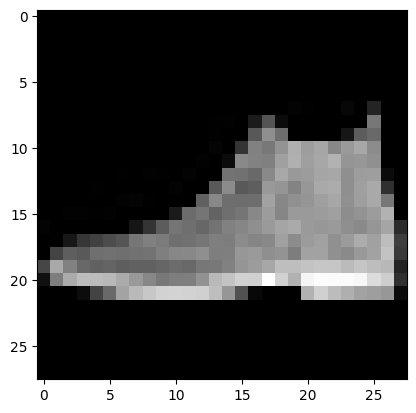

In [49]:
#1-4

indices = [1,4,5,11,0] # 각 클래스가 가장 첫번째로 등장하는 인덱스

idx = indices[4] # 원하는 클래스 번호 입력
img = test_X[idx]
pred = model.predict(tf.expand_dims(img, axis=0))
plt.imshow(img,'gray')
print(test_Y[idx], pred)

In [31]:
#2-1

# Load fashion MNIST dataset
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_X, train_Y), (test_X, test_Y) = fashion_mnist.load_data()

print("[previous]")
print(train_X.shape, train_Y.shape)
print(test_X.shape, test_Y.shape)
print("test_Y: ", end='')
print(test_Y[:10], end='\n\n')

# Modify dataset
label_map = {3:0, 5:1, 8:2}

train_mask = np.isin(train_Y, list(label_map.keys()))
train_X = train_X[train_mask]
train_Y = np.array([label_map[y] for y in train_Y[train_mask]])

test_mask = np.isin(test_Y, list(label_map.keys()))
test_X = test_X[test_mask]
test_Y = np.array([label_map[y] for y in test_Y[test_mask]])

print("[after]")
print(train_X.shape, train_Y.shape)
print(test_X.shape, test_Y.shape)
print("test_Y: ", end='')
print(test_Y[:10])

# Normalize intensities between 0 and 1
train_X = train_X / 255.0
test_X = test_X / 255.0

[previous]
(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)
test_Y: [9 2 1 1 6 1 4 6 5 7]

[after]
(18000, 28, 28) (18000,)
(3000, 28, 28) (3000,)
test_Y: [1 1 0 2 1 0 2 2 0 0]


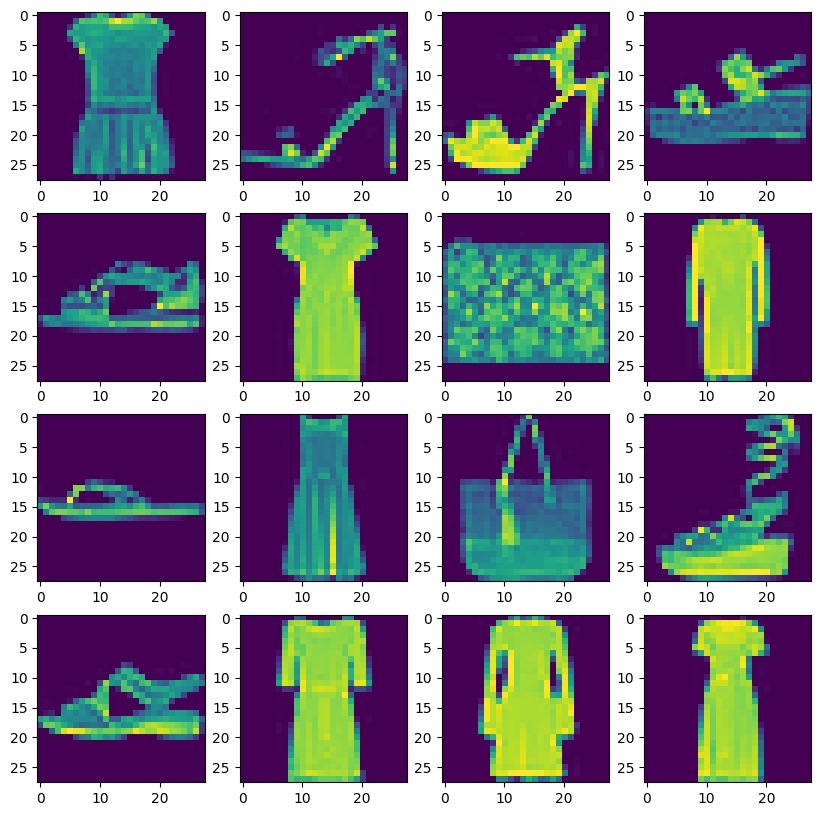

[0 1 1 1 1 0 2 0 1 0 2 1 1 0 0 0]


In [32]:
plt.figure(figsize=(10, 10))
for c in range(16):
  plt.subplot(4,4,c+1)
  plt.imshow(train_X[c])
plt.show()
print(train_Y[:16])

In [52]:
#2-2

model = tf.keras.Sequential([
  tf.keras.layers.Conv2D(input_shape=(28,28,1), kernel_size=(5,5), strides=(1, 1), padding='same', filters=20),
  tf.keras.layers.Activation('relu'),
  tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'),

  tf.keras.layers.Conv2D(kernel_size=(5,5), strides=(1, 1), padding='same', filters=50),
  tf.keras.layers.Activation('relu'),
  tf.keras.layers.MaxPooling2D(pool_size=(2,2), strides=(2,2), padding='valid'),

  tf.keras.layers.Flatten(),

  tf.keras.layers.Dense(units=500),
  tf.keras.layers.Activation('relu'),

  tf.keras.layers.Dense(units=3),
  tf.keras.layers.Softmax()
])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 20)     │           520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 28, 28, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 50)     │        25,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 14, 14, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2450)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 500)            │     1,225,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 3)              │         1,503 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_1 (Softmax)             │ (None, 3)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,252,573 (4.78 MB)

 Trainable params: 1,252,573 (4.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9579 - loss: 0.1279 - val_accuracy: 0.9924 - val_loss: 0.0300
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9923 - loss: 0.0230 - val_accuracy: 0.9949 - val_loss: 0.0168
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9958 - loss: 0.0151 - val_accuracy: 0.9951 - val_loss: 0.0143
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9978 - loss: 0.0083 - val_accuracy: 0.9962 - val_loss: 0.0127
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9981 - loss: 0.0068 - val_accuracy: 0.9960 - val_loss: 0.0118
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9986 - loss: 0.0038 - val_accuracy: 0.9958 - val_loss: 0.0149
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9983 - loss: 0.0053 - val_accuracy: 0.9973 - val_loss: 0.0091
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9996 - loss: 0.0012 - val_accuracy: 0.

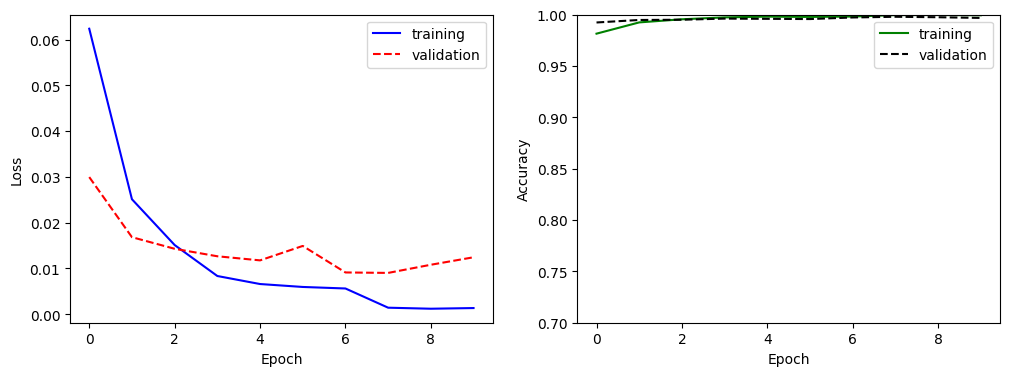

[0.013776934705674648, 0.996666669845581]

In [53]:
#2-3

# Train model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_X, train_Y , batch_size=36, epochs=10, validation_split=0.25)

# Show training history
plt.figure(figsize=(12, 4)), plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='training')
plt.plot(history.history['val_loss'], 'r--', label='validation')
plt.xlabel('Epoch'), plt.ylabel('Loss'), plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'g-', label='training')
plt.plot(history.history['val_accuracy'], 'k--', label='validation')
plt.xlabel('Epoch'), plt.ylabel('Accuracy'), plt.ylim(0.7, 1), plt.legend()
plt.show()

# Evaluate the model using the test dataset
model.evaluate(test_X, test_Y , verbose=False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1 [[3.2646370e-09 1.0000000e+00 1.2020958e-08]]


np.int64(1)

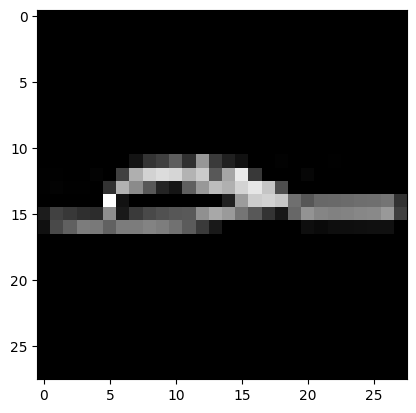

In [58]:
#2-4
indices = [2,0,3] # 각 클래스가 가장 첫번째로 등장하는 인덱스

idx = indices[1] # 원하는 클래스 번호 입력
img = test_X[idx]
pred = model.predict(tf.expand_dims(img, axis=0))
plt.imshow(img,'gray')
print(test_Y[idx], pred)

In [15]:
#3-1

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load CIFAR-10 Dataset
(train_X, train_Y), (test_X, test_Y) = tf.keras.datasets.cifar10.load_data()
print(train_X.shape, test_X.shape)

train_Y = train_Y.flatten()
test_Y  = test_Y.flatten()

print("[previous]")
print(train_X.shape, train_Y.shape)
print(test_X.shape, test_Y.shape)
print("test_Y: ", end='')
print(test_Y[:10], end='\n\n')

# Modify dataset
label_map = {0:0, 1:1, 5:2, 8:3}

train_mask = np.isin(train_Y, list(label_map.keys()))
train_X = train_X[train_mask]
train_Y = np.array([label_map[y] for y in train_Y[train_mask]])

test_mask = np.isin(test_Y, list(label_map.keys()))
test_X = test_X[test_mask]
test_Y = np.array([label_map[y] for y in test_Y[test_mask]])

print("[after]")
print(train_X.shape, train_Y.shape)
print(test_X.shape, test_Y.shape)
print("test_Y: ", end='')
print(test_Y[:10])

(50000, 32, 32, 3) (10000, 32, 32, 3)
[previous]
(50000, 32, 32, 3) (50000,)
(10000, 32, 32, 3) (10000,)
test_Y: [3 8 8 0 6 6 1 6 3 1]

[after]
(20000, 32, 32, 3) (20000,)
(4000, 32, 32, 3) (4000,)
test_Y: [3 3 0 1 1 0 2 3 2 3]


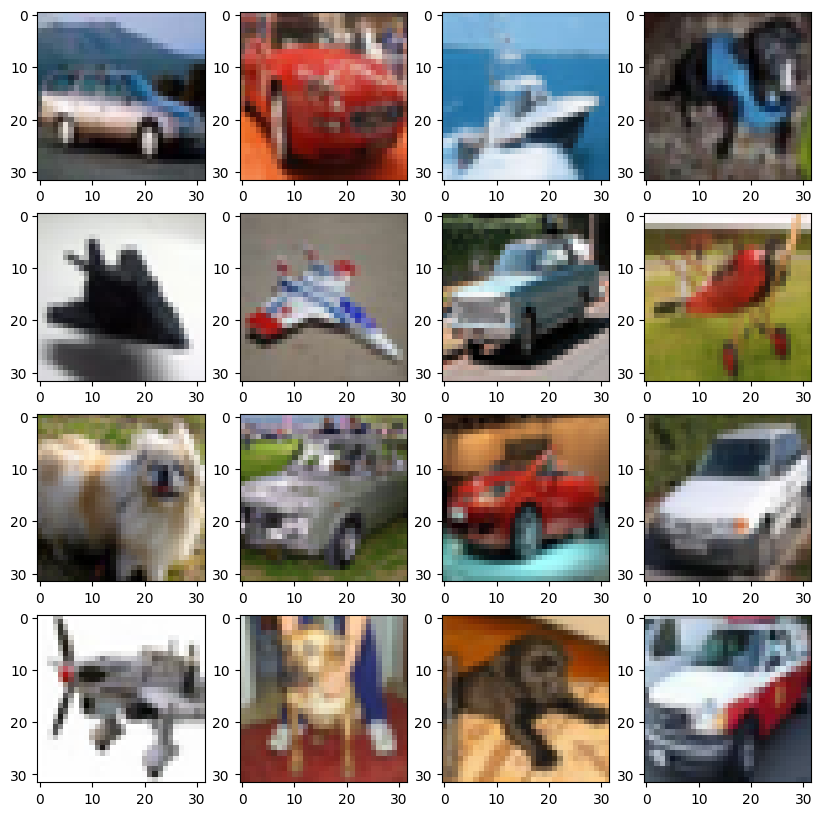

[1 1 3 2 0 0 1 0 2 1 1 1 0 2 2 1]


In [3]:
plt.figure(figsize=(10, 10))
for c in range(16):
  plt.subplot(4,4,c+1)
  plt.imshow(train_X[c])
plt.show()
print(train_Y[:16])

In [16]:
#3-2

# Preprocessing
train_X = tf.keras.applications.vgg16.preprocess_input(train_X)
test_X = tf.keras.applications.vgg16.preprocess_input(test_X)

# Load VGG16 with include_top=False
base_model = tf.keras.applications.VGG16(input_shape=[32,32,3], include_top=False, weights='imagenet')
x = base_model.output
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
x = tf.keras.layers.Dense(32, activation='relu')(x)
predictions = tf.keras.layers.Dense(4, activation='softmax')(x)
model = tf.keras.Model(inputs=base_model.input, outputs=predictions)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,749,732 (56.27 MB)

 Trainable params: 14,749,732 (56.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - accuracy: 0.9205 - loss: 0.2150 - val_accuracy: 0.8076 - val_loss: 0.7548
Epoch 2/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9245 - loss: 0.1932 - val_accuracy: 0.8068 - val_loss: 0.7566
Epoch 3/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9376 - loss: 0.1667 - val_accuracy: 0.8072 - val_loss: 0.8144
Epoch 4/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9451 - loss: 0.1458 - val_accuracy: 0.7988 - val_loss: 0.8969
Epoch 5/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9484 - loss: 0.1320 - val_accuracy: 0.7996 - val_loss: 0.9043
Epoch 6/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9444 - loss: 0.1477 - val_accuracy: 0.8008 - val_loss: 0.9099
Epoch 7/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9540 - loss: 0.1199 - val_accuracy: 0.8034 - val_loss: 0.9814
Epoch 8/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9601 - loss: 0.1112 - val_acc

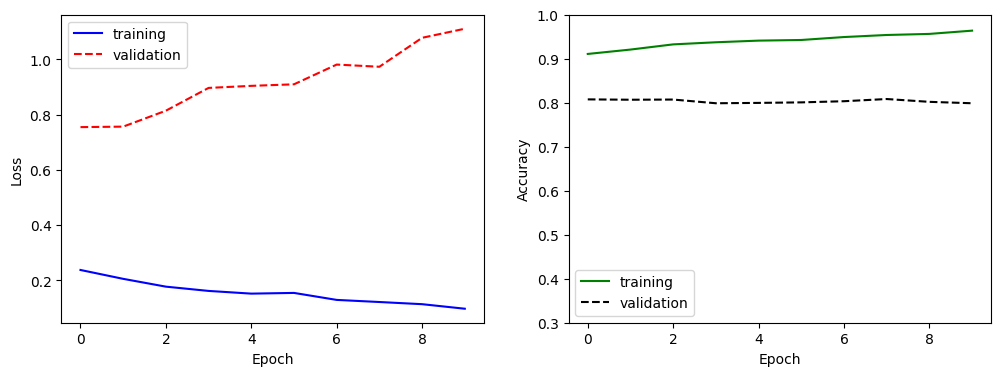

[1.102850079536438, 0.8015000224113464]

In [70]:
#3-3

# Freeze pretrained layers
for layer in model.layers[:19]:
  layer.trainable = False
for layer in model.layers[19:]:
  layer.trainable = True

# Train model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_X, train_Y , batch_size=36, epochs=10, validation_split=0.25)

# Show training history
plt.figure(figsize=(12, 4)), plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='training')
plt.plot(history.history['val_loss'], 'r--', label='validation')
plt.xlabel('Epoch'), plt.ylabel('Loss'), plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'g-', label='training')
plt.plot(history.history['val_accuracy'], 'k--', label='validation')
plt.xlabel('Epoch'), plt.ylabel('Accuracy'), plt.ylim(0.3, 1), plt.legend()
plt.show()

# Evaluate the model using the test dataset
model.evaluate(test_X, test_Y , verbose=False)

Epoch 1/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 34s 64ms/step - accuracy: 0.3033 - loss: 2.9596 - val_accuracy: 0.5356 - val_loss: 0.9960
Epoch 2/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.5636 - loss: 0.9148 - val_accuracy: 0.7202 - val_loss: 0.6651
Epoch 3/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.7383 - loss: 0.5884 - val_accuracy: 0.8114 - val_loss: 0.4723
Epoch 4/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.8434 - loss: 0.4369 - val_accuracy: 0.8344 - val_loss: 0.4725
Epoch 5/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.8832 - loss: 0.3416 - val_accuracy: 0.9006 - val_loss: 0.3122
Epoch 6/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.9134 - loss: 0.2574 - val_accuracy: 0.9050 - val_loss: 0.2774
Epoch 7/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - accuracy: 0.9269 - loss: 0.2141 - val_accuracy: 0.9056 - val_loss: 0.2752
Epoch 8/10
417/417 ━━━━━━━━━━━━━━━━━━━━ 22s 53ms/step - accuracy: 0.9399 - loss: 0.1815 - 

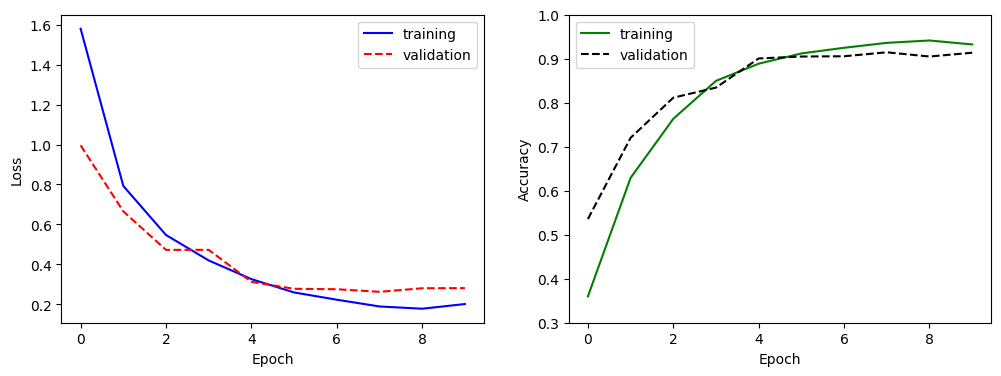

[0.2881890535354614, 0.909250020980835]

In [17]:
#3-4

# Unfreeze the whole network
for layer in model.layers:
  layer.trainable = True

# Train model
model.compile(optimizer=tf.keras.optimizers.Adam(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_X, train_Y , batch_size=36, epochs=10, validation_split=0.25)

# Show training history
plt.figure(figsize=(12, 4)), plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], 'b-', label='training')
plt.plot(history.history['val_loss'], 'r--', label='validation')
plt.xlabel('Epoch'), plt.ylabel('Loss'), plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], 'g-', label='training')
plt.plot(history.history['val_accuracy'], 'k--', label='validation')
plt.xlabel('Epoch'), plt.ylabel('Accuracy'), plt.ylim(0.3, 1), plt.legend()
plt.show()

# Evaluate the model using the test dataset
model.evaluate(test_X, test_Y , verbose=False)

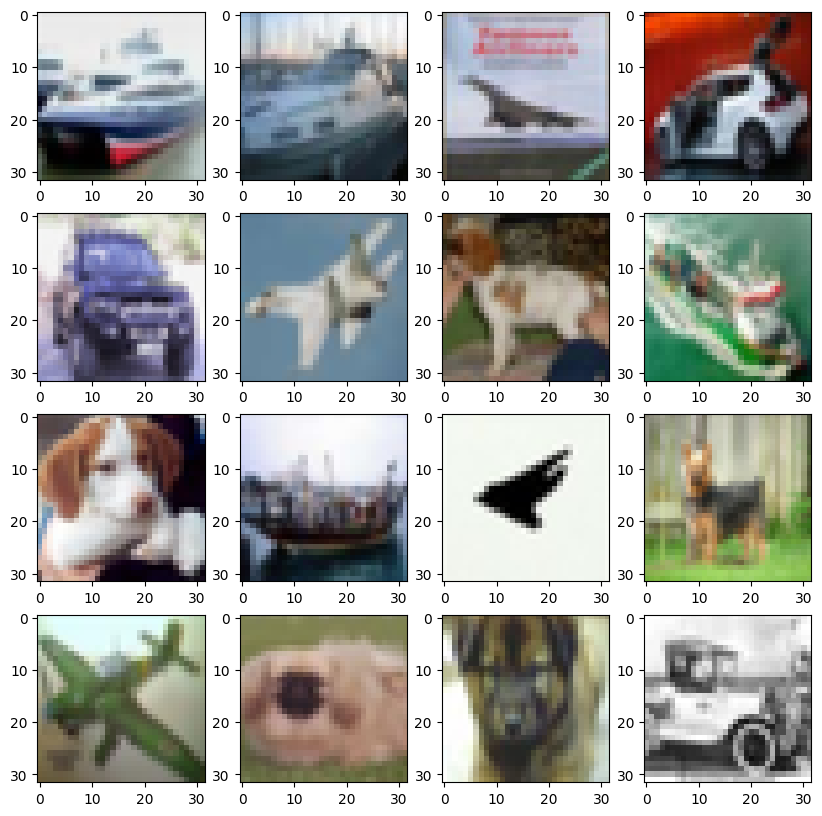

[3 3 0 1 1 0 2 3 2 3 0 2 0 2 2 1]


In [26]:
plt.figure(figsize=(10, 10))
for c in range(16):
  plt.subplot(4,4,c+1)
  plt.imshow(test_X[c])
plt.show()
print(test_Y[:16])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
3 [[0.04243203 0.06830814 0.0060644  0.8831954 ]]


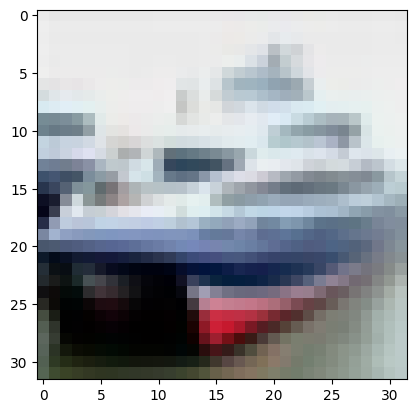

In [30]:
#3-5

# 전처리 전의 이미지 다시 업로드, dataset 재구성
(train_X, train_Y), (test_X, test_Y) = tf.keras.datasets.cifar10.load_data()
train_Y = train_Y.flatten()
test_Y  = test_Y.flatten()
label_map = {0:0, 1:1, 5:2, 8:3}
test_mask = np.isin(test_Y, list(label_map.keys()))
test_X = test_X[test_mask]
test_Y = np.array([label_map[y] for y in test_Y[test_mask]])

indices = [5,3,6,0] # 각 클래스가 가장 첫번째로 등장하는 인덱스

# Evaluate a single image
idx = indices[3] # 원하는 클래스 번호 입력
img = test_X[idx]
pre_img = tf.expand_dims(img, axis=0)
pre_img = tf.keras.applications.vgg16.preprocess_input(pre_img)
pred = model.predict(pre_img)
plt.imshow(img)
np.argmax(pred)
print(test_Y[idx], pred)